In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator

In [2]:
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23265408/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [3]:
from src.dataloading import ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel

sl = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)

ps.forecast('test')
raw_f1 = ps.show_forecasts([26], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([26], 'test')

f1 = (raw_f1
      .labels.change_suptitle('Persistence model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','persistence model'])
      .change_figsize(10,5).legend.move('upper left'))

f2 = (raw_f2
      .labels.change_suptitle('Climateology model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climateology model'])
      .change_figsize(10,5).legend.move('upper left'))

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from src.models import NodeRFModel

rf = NodeRFModel(sl, verbose = -1)
rf.set_global_hparams()
rf.set_model_hparams()
rf.train()
rf.forecast('test')
raw_f3 = rf.show_forecasts([26], 'test')


f3 = (raw_f3
      .labels.change_suptitle('Random Forest model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climateology model'])
      .change_figsize(10,5).legend.move('upper left'))


In [5]:
from src.evaluation import Evaluator

evaluation = Evaluator([ps,cm,rf]).add_evaluation()

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.11it/s]


In [7]:
predicted_timeseries_raw = evaluation.plotter.plot_timeseries([15,26,223,356], 0)

In [8]:
from src.plotting import ManagedFigure

predicted_timeseries = (predicted_timeseries_raw
        .labels.change_suptitle('Predicted timeseries by baseline models in 4 Kreisen', fontweight = 'bold', fontsize = 14)         
        .labels.set_suptitle_y(y=1.05)
        .labels.change_title(title = 'Hamburg',  ax = 0, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Hannover', ax = 1, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Munich',   ax = 2, fontsize = 12, fontweight = 'bold')
        .labels.change_title(title = 'Dresden',  ax = 3, fontsize = 12, fontweight = 'bold')   
        .labels.change_ylab('incidence', ax = 0)
        .labels.change_ylab('incidence', ax = 2)
        .labels.set_tag('A', y = 1.04, ax = 0)
        .labels.set_tag('B', y = 1.04, ax = 1)
        .labels.set_tag('C', y = 1.04, ax = 2)
        .labels.set_tag('D', y = 1.04, ax = 3)                        
        .change_figsize(14,10)         
        .layout.grid('off')
        )




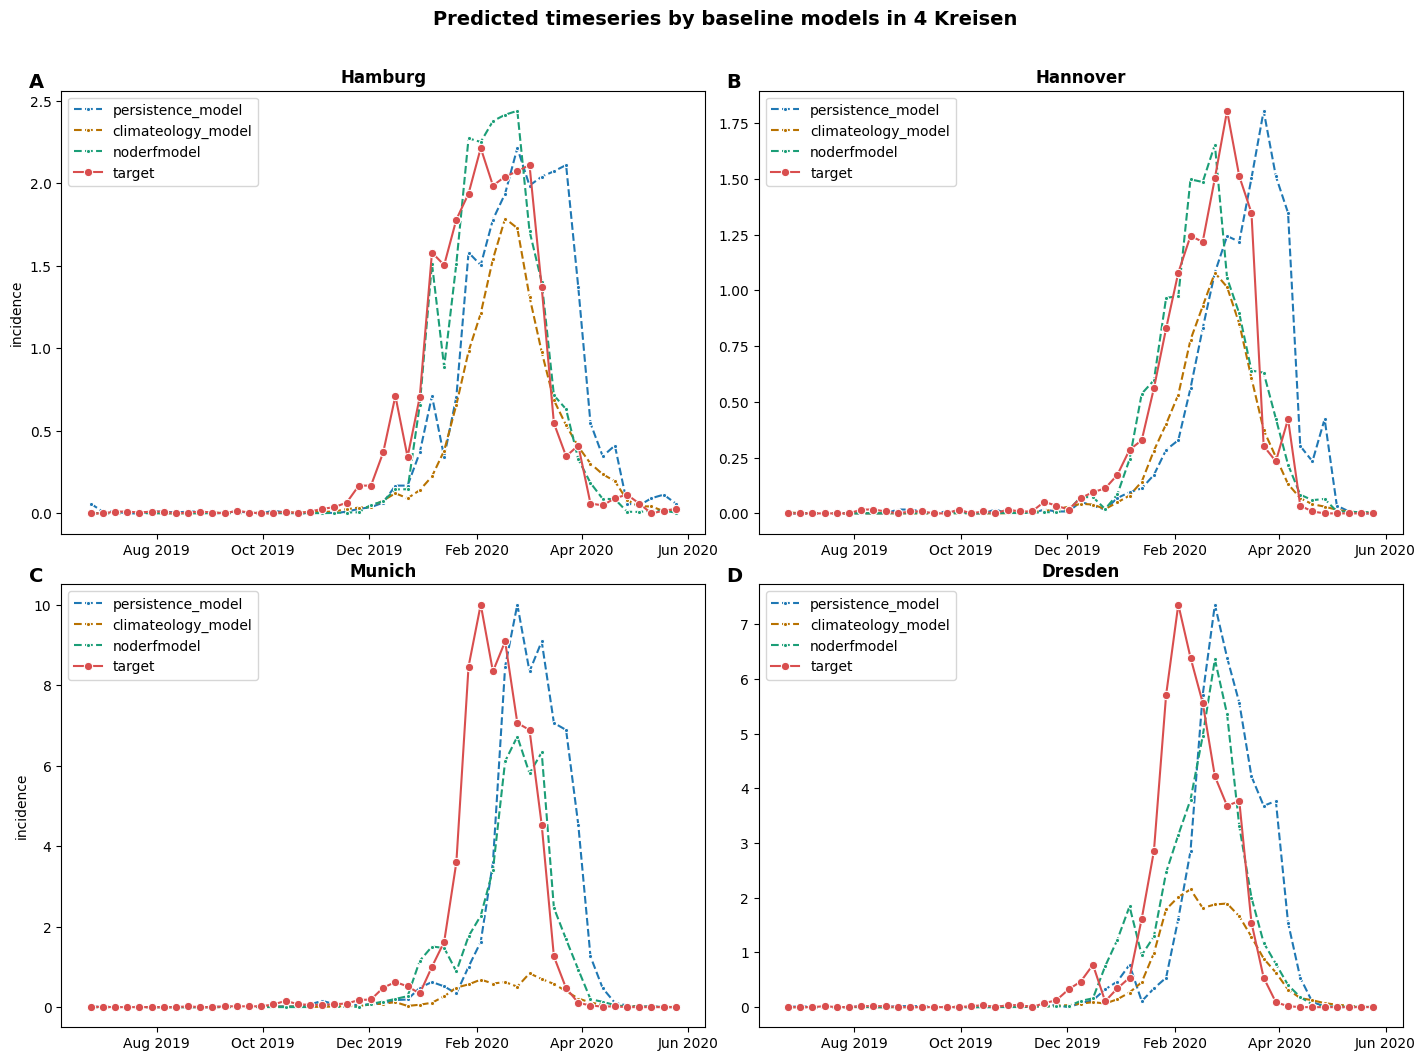

In [9]:
predicted_timeseries.show()

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

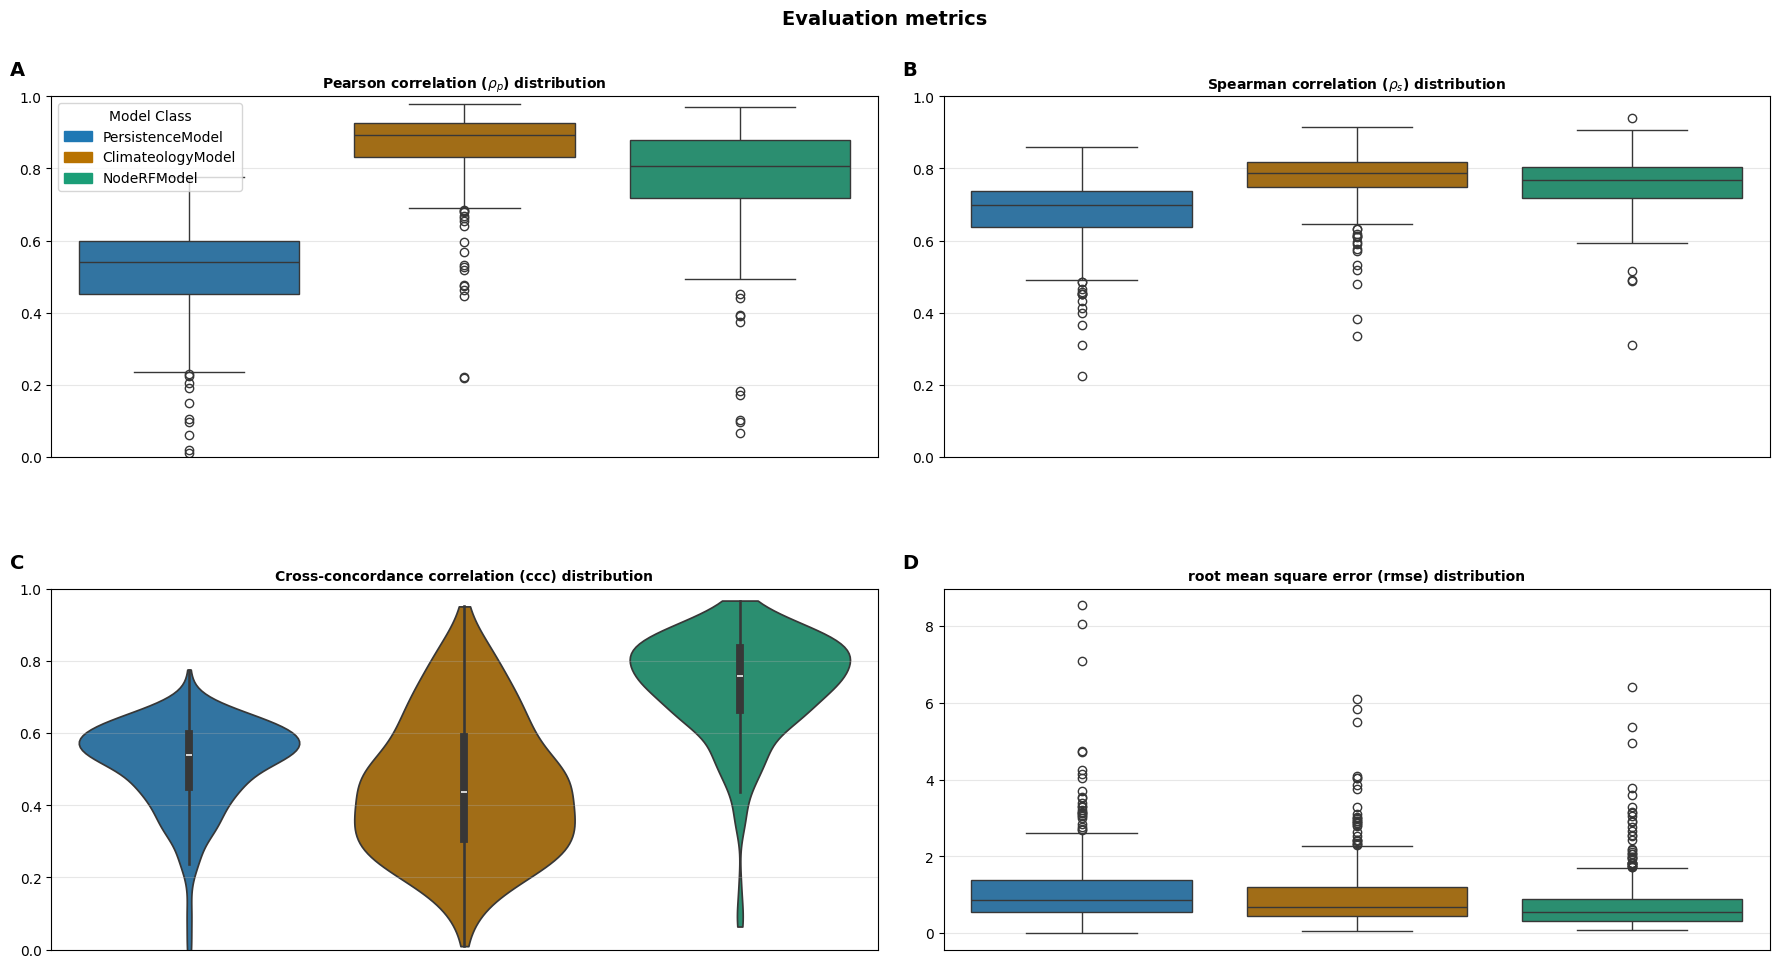

In [11]:

f_merged_raw    = evaluation.plotter.plot_metric_compilation(subfig_size = (9,5));

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation metrics', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([])
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)             
    )
f_merged.show()

TEXT